# **Plotting Venn Diagrams**

In [1]:
from pyXLMS import __version__

print(f"Installed pyXLMS version: {__version__}")

Installed pyXLMS version: 1.1.2


In [2]:
from pyXLMS import pipelines
from pyXLMS import plotting

All plotting functionality is available via the `plotting` submodule. We also import the `pipelines` submodule here for reading crosslink-spectrum-match result files and doing some standard data transformations.

In [3]:
%%capture output

msannika = pipelines.pipeline(
    "../../data/ms_annika/XLpeplib_Beveridge_QEx-HFX_DSS_R1_CSMs.txt",
    engine="MS Annika",
    crosslinker="DSS",
)
csms_msannika = msannika["crosslink-spectrum-matches"]

maxquant = pipelines.pipeline(
    "../../data/maxquant/run1/crosslinkMsms.txt", engine="MaxQuant", crosslinker="DSS"
)
csms_maxquant = maxquant["crosslink-spectrum-matches"]

plink = pipelines.pipeline(
    "../../data/plink2/Cas9_plus10_2024.06.20.filtered_cross-linked_spectra.csv",
    engine="pLink",
    crosslinker="DSS",
)
csms_plink = plink["crosslink-spectrum-matches"]

We read crosslink-spectrum-matches from three different search engines (MS Annika, MaxQuant, pLink) that searched the same RAW file using `pipelines.pipepline()`. Additionally, the pipeline will automatically filter for unique crosslink-spectrum-matches, validate them for estimated 1% FDR and only keep target-target hits. You can read more about the pipeline here: [**docs**](https://hgb-bin-proteomics.github.io/pyXLMS/pyXLMS.pipelines.html#pyXLMS.pipelines.pipeline).

We use the `%%capture` magic here to not display the information that is printed by `pipelines.pipeline()` in order to not clutter the notebook, feel free to disable this in your own run to see exactly what `pipelines.pipeline()` does!

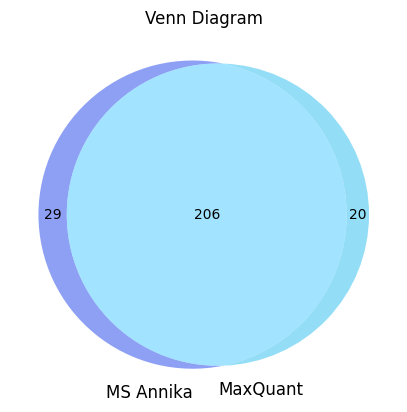

In [4]:
fig, ax = plotting.plot_venn_diagram(
    csms_msannika,
    csms_maxquant,
    labels=["MS Annika", "MaxQuant"],
    colors=["#4361EE", "#4CC9F0"],
    figsize=(5.0, 5.0),
    filename_prefix="MS Annika & MaxQuant",
)

We can plot the 2-set venn diagram for MS Annika and MaxQuant crosslink-spectrum-matches by passing them as the first two arguments. You can control the labels and colors via the `labels` and `colors` parameters. The default figure size is 10 by 10 inches and does not need to be set explicitly, we just used a smaller one here for demonstration purposes. The `filename_prefix` parameter is also optional, if it is given the plot is saved four times: once without the title in `.png` and `.svg` format, and once with the title in `.png` and `.svg` format.

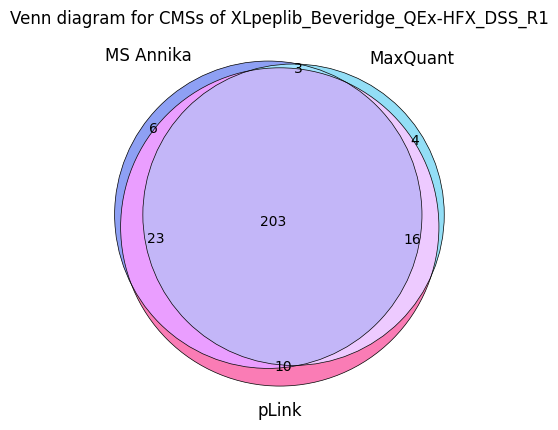

In [5]:
fig, ax = plotting.plot_venn_diagram(
    csms_msannika,
    csms_maxquant,
    csms_plink,
    labels=["MS Annika", "MaxQuant", "pLink"],
    contour=True,
    title="Venn diagram for CMSs of XLpeplib_Beveridge_QEx-HFX_DSS_R1",
    figsize=(5.0, 5.0),
)

We can plot the 3-set venn diagram for MS Annika, MaxQuant and pLink crosslink-spectrum-matches by passing them as the first three arguments. This time we also specify `contour=True` to draw a contour around the circles and additionally specify a title for our plot via the `title` parameter. Since we did not specify a `filename_prefix` the plot is not saved to disk. There are also other parameters that can be set to tune your plot like `alpha` and `linewidth`, you can read more about all the possible parameters here: [**docs**](https://hgb-bin-proteomics.github.io/pyXLMS/pyXLMS.plotting.html#pyXLMS.plotting.plot_venn_diagram).